# Spotify Lab: Simple Vector Recommendations

**Name(s):** 

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## What You Will Submit
**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.


### Parts 1-4: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern. Complete the notebook and answer the yellow prompts in your own words. Your answers should focus on what each scoring rule rewards and whether the recommendations seem useful.


### Part 5: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Part 6: Improvement to the system

Can you make an improvement to your recommender system by implementing a change?

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.



## Setup

We will use only `pandas`, `numpy`, and `seaborn`.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

songs = pd.read_csv("./data/song_vectors.csv.gz")
vocab = pd.read_csv("./data/vocabulary.csv")
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist()
meta_cols = [col for col in songs.columns if col not in word_cols]

X = songs[word_cols].to_numpy(dtype=float)

print("songs:", songs.shape)
print("word-count matrix:", X.shape)
print("top-40 benchmark:", top_40.shape)

songs: (8000, 816)
word-count matrix: (8000, 800)
top-40 benchmark: (560, 6)


In [9]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Inspect One Song Vector

Each row of `X` is one song vector. We will start with a single query song so the scoring rules are easier to see.

In [10]:
query_row = 0
query_track_id = songs.loc[query_row, "track_id"]
query = X[query_row]

songs.loc[[query_row], ["artist_name", "song_title", "genre", "n_words", "nnz_words"]]

,artist_name,song_title,genre,n_words,nnz_words
0,Gary Moore,What Are We Here For,blues,218,80


In [11]:
word_counts = pd.DataFrame({
    "word": word_cols,
    "count": query.astype(int),
})

word_counts.query("count > 0").sort_values("count", ascending=False).head(15)

,word,count
748,we,27
31,are,10
245,for,9
475,of,7
753,what,6
336,it,6
306,here,6
295,have,6
489,our,5
676,through,5


<div class="alert alert-block alert-warning">

What are the most common words in the query song? Do they look like words that would be useful for recommending similar songs? Why or why not?

</div>

## Part 2: Dot Product

The dot product is:

$$
x \cdot y = \sum_j x_j y_j
$$

It gets large when two songs use many of the same words many times. That can be useful, but it can also reward long or repetitive songs.

In [5]:
def top_matches(scores, query_track_id, k=10, query_artist_id=None):
    results = songs[meta_cols].copy()
    results["score"] = scores

    results = results[results["track_id"] != query_track_id]
    if query_artist_id is not None:
        results = results[results["artist_id"] != query_artist_id]

    return results.sort_values("score", ascending=False).head(k)

In [6]:
dot_scores = X @ query
dot_matches = top_matches(dot_scores, query_track_id, k=10)

dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

,artist_name,song_title,genre,n_words,score
1582,The Prodigy,We Gonna Rock,electronic,312,2136.0
6290,Lauryn Hill,Interlude 5,r&b/soul,1903,2115.0
5601,Bowling For Soup,Here We Go,punk,374,1939.0
1930,Ladyhawke,Crazy World,electronic,340,1680.0
6997,Ziggy Marley And The Melody Makers,We Propose,reggae,297,1656.0
3053,The Streets,Weak Become Heroes,hip hop,754,1654.0
2971,Black Eyed Peas,Communication,hip hop,592,1615.0
2874,Hollywood Undead,Undead,hip hop,831,1476.0
5840,Rise Against,Survive,punk,324,1383.0
3085,Binary Star,Indy 500,hip hop,977,1331.0


[Text(0.5, 1.0, 'Dot product top matches'),
 Text(0.5, 0, 'dot product'),
 Text(0, 0.5, '')]

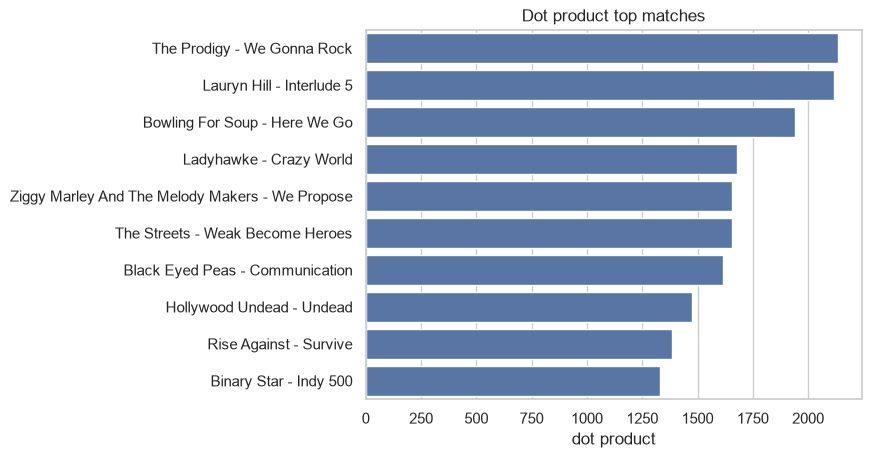

In [7]:
plot_data = dot_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score")
ax.set(title="Dot product top matches", xlabel="dot product", ylabel="")

<div class="alert alert-block alert-warning">

Look at the dot-product matches. Do they seem similar to the query song, or does the score seem to reward song size/repetition? Use at least one specific song from the table in your answer.

</div>

## Part 3: Cosine Similarity

Cosine similarity divides the dot product by the lengths of the two vectors:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

This compares the direction of the word-count profiles. A long song does not automatically win just because it has more words.

In [ ]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    denominators = np.linalg.norm(matrix, axis=1) * np.linalg.norm(query_vector)

    return np.divide(
        numerators,
        denominators,
        out=np.zeros(len(numerators)),
        where=denominators != 0,
    )

In [ ]:
cos_scores = cosine_scores(X, query)
cos_matches = top_matches(cos_scores, query_track_id, k=10)

cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

In [ ]:
plot_data = cos_matches.copy()
plot_data["song"] = plot_data["artist_name"] + " - " + plot_data["song_title"]

ax = sns.barplot(data=plot_data, y="song", x="score")
ax.set(title="Cosine similarity top matches", xlabel="cosine similarity", ylabel="")

<div class="alert alert-block alert-warning">

Compare the dot-product matches to the cosine matches. Which method looks more like a similar-song engine? Which method looks more like it is rewarding raw word-count mass?

</div>

## Part 4: TF-IDF

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [ ]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

<div class="alert alert-block alert-warning">

What do you notice about the lowest-IDF words and highest-IDF words? Why might this matter for a recommendation system?

</div>

In [ ]:
query_tfidf = TFIDF[query_row]

tfidf_dot_scores = TFIDF @ query_tfidf
tfidf_dot_matches = top_matches(tfidf_dot_scores, query_track_id, k=10)

tfidf_dot_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

In [ ]:
tfidf_cos_scores = cosine_scores(TFIDF, query_tfidf)
tfidf_cos_matches = top_matches(tfidf_cos_scores, query_track_id, k=10)

tfidf_cos_matches[["artist_name", "song_title", "genre", "n_words", "score"]]

<div class="alert alert-block alert-warning">

Compare raw dot product, raw cosine, TF-IDF dot product, and TF-IDF cosine. Which recommendation list seems best for this query song? Give one specific example.

</div>

## Part 5: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?

<div class="alert alert-block alert-warning">

Which method has the best precision@3? Does that agree with your judgment from the single-query examples, or does the benchmark change your view?

</div>

## Part 6: Test an Adjustment

A recommendation system is a design choice. Investigate your previous results, think of a promising change to make in the system, and compare it to the pevious methods. Did the adjustment improve results? (It's fine if it didn't.)

## Final Report

State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.
